In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
import joblib
from scipy.ndimage import uniform_filter1d
from ovo_svm import OvO_SVM
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from utils.Hog import HoG, calc_gradients, predict_char
from utils.MSER import merge_boxes, filter_char_boxes, merge_char_words, get_word_boxes, sort_boxes_reading_order, sort_word_chars
from utils.text_detector import extract_word_images

In [2]:
model = OvO_SVM().load("./models/from_scratch_SVM")
le = joblib.load("./models/from_scratch_SVM/OvO_SVM_label_encoder.joblib")


In [3]:
img = cv2.imread("./images/ocr.jpeg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

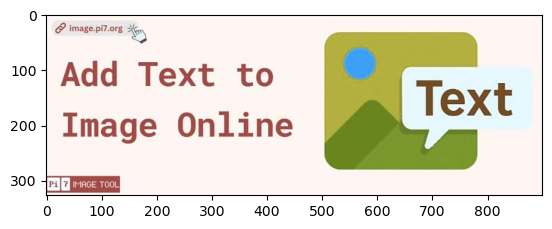

In [4]:
plt.imshow(img)

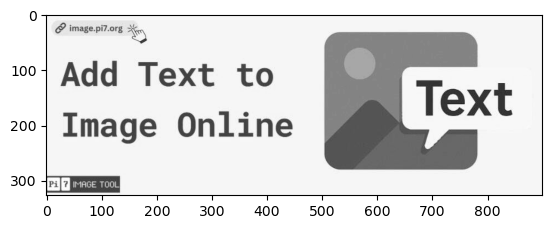

In [5]:
plt.imshow(gray, cmap='gray')

In [6]:
mser = cv2.MSER_create()
# mser.setMinArea()

Number of regions: 793
Number of boxes: 793
Number of unique boxes: 30


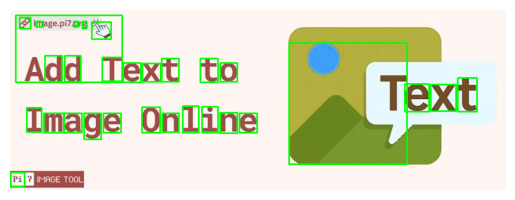

In [7]:
plt.axis('off')

regions, boxes = mser.detectRegions(gray)
unique_boxes = set(tuple(b) for b in boxes)
unique_boxes = [list(b) for b in unique_boxes]
unique_boxes = merge_boxes(unique_boxes, threshold=0.3)
unique_boxes = filter_char_boxes(unique_boxes, lower_bound=0.1, higher_bound=2.5)

print(f"Number of regions: {len(regions)}")
print(f"Number of boxes: {len(boxes)}")
print(f"Number of unique boxes: {len(unique_boxes)}")

img_copy = img.copy()
for i in range(len(unique_boxes)):
    x, y, w, h = unique_boxes[i]
    cv2.rectangle(img_copy, (x, y), (x + w, y + h), (0, 255, 0), 2)
plt.imshow(img_copy)
plt.show()
box_0 = unique_boxes[0]
char_0 = gray[box_0[1]:box_0[1]+box_0[3], box_0[0]:box_0[0]+box_0[2]]


In [8]:
words = merge_char_words(unique_boxes, x_thresh=10, y_thresh=20)
print(f"Number of words: {len(words)}")

Number of words: 12


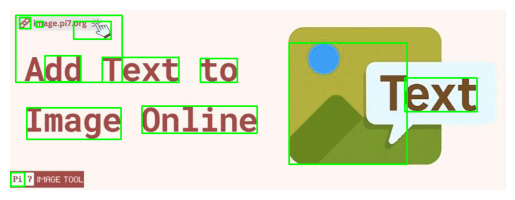

12


In [9]:
word_boxes = get_word_boxes(words)

img_copy = img.copy()

for (x, y, w, h) in word_boxes:
    cv2.rectangle(
        img_copy,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

plt.imshow(img_copy)
plt.axis("off")
plt.show()
print(len(words))

In [10]:
char_non_char_model = joblib.load("./models/is_char_svm_model.joblib")

Number of words: 11
[0.04053828510199196, 0.03989365358153262, 0.03943266843907151]
1.0161587486375965
Predicted label for test image: J


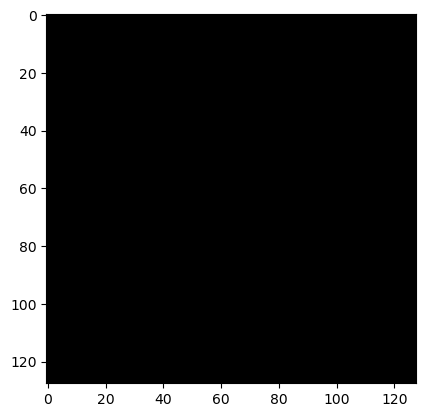

[0.03996602062325269, 0.039137614862596405, 0.03733441310298358]
1.021166485580806
Predicted label for test image: a


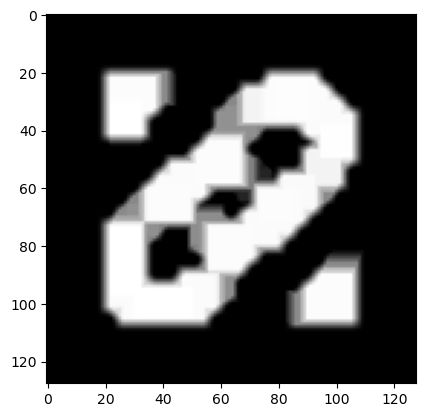

[0.041855557837251846, 0.04155258260870963, 0.03839663753877771]
1.007291369381183
Predicted label for test image: M


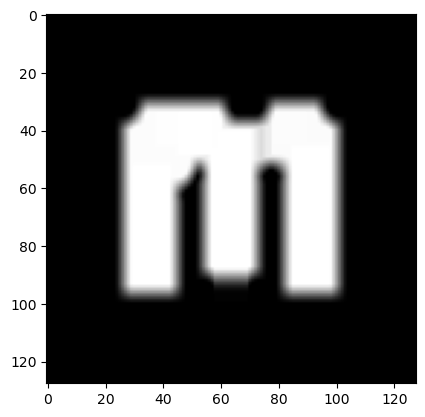

[0.03944319755875294, 0.039187423245991754, 0.038620583047208897]
1.0065269489947224
Predicted label for test image: D


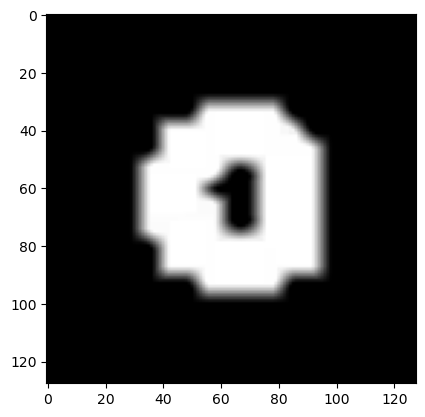

[0.040827155129191044, 0.03731634490652296, 0.03730057342711547]
1.094082371450436
Predicted label for test image: B


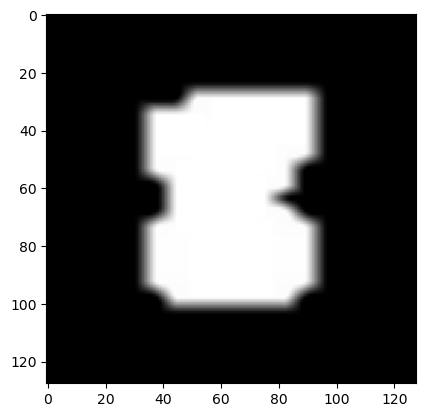

[0.037513995325037866, 0.037221449305061466, 0.03564067241902627]
1.0078596085170874
Predicted label for test image: U


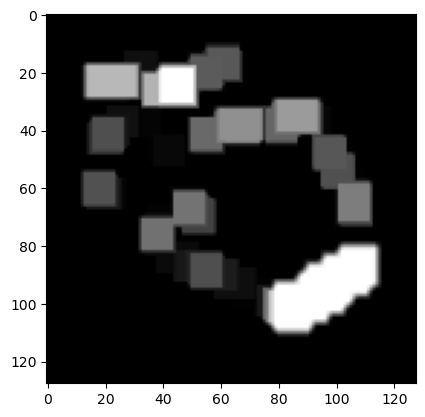

[0.04053828510199196, 0.03989365358153262, 0.03943266843907151]
1.0161587486375965
Predicted label for test image: J


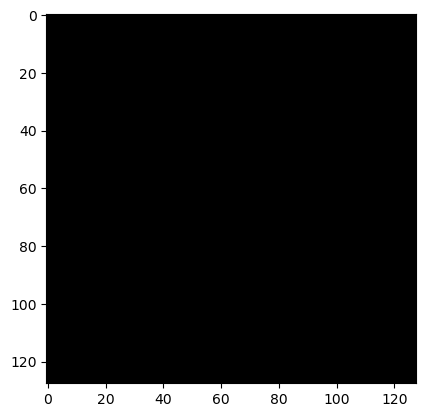

[0.04199952664393475, 0.040617714795248935, 0.038294526331312397]
1.0340199308516353
Predicted label for test image: d


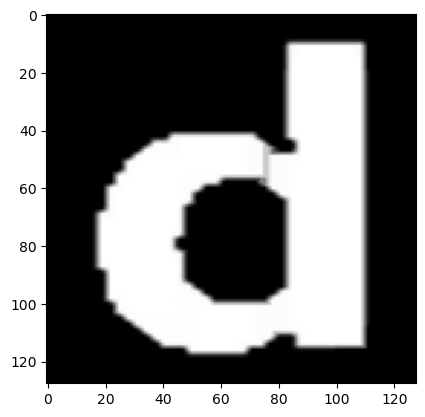

[0.04192972397559738, 0.039528888358465804, 0.03780825400051022]
1.0607362290424087
Predicted label for test image: d


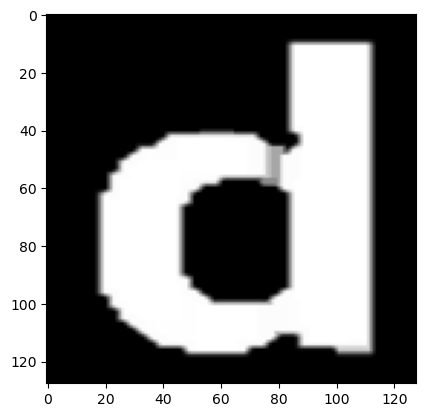

[0.04223283272452479, 0.0408024049260155, 0.03992308596442564]
1.0350574384304798
Predicted label for test image: T


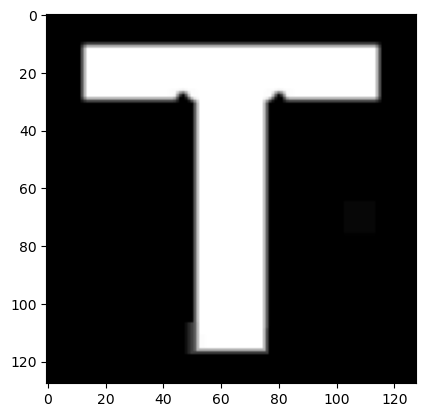

[0.042292183827838656, 0.039795769091299144, 0.03862590509416129]
1.0627306568899888
Predicted label for test image: e


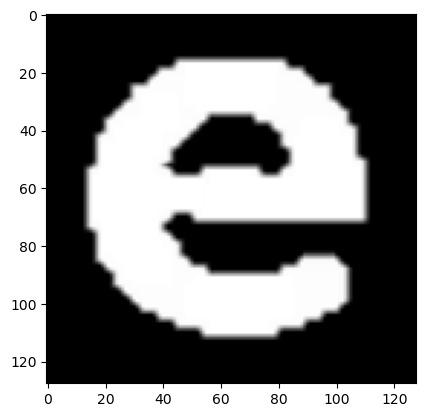

[0.04224136480606461, 0.038774935270220905, 0.03847830055073219]
1.0893987188292205
Predicted label for test image: X


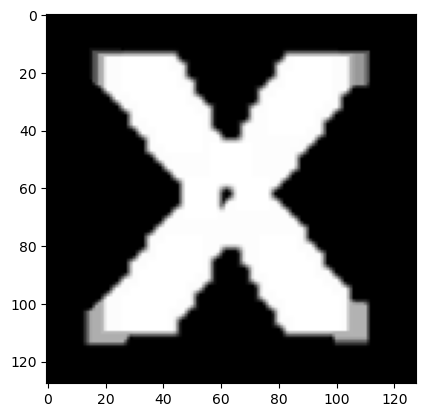

[0.04151628361890183, 0.03610856613339932, 0.035962729122066654]
1.1497627312456622
Predicted label for test image: t


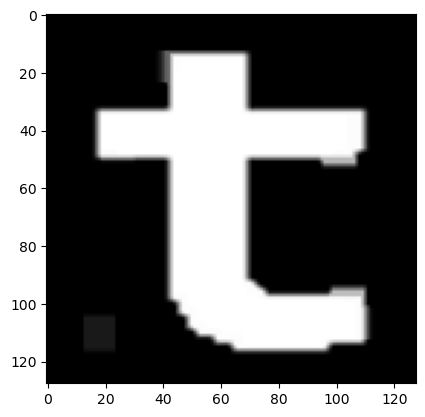

[0.04188307733392137, 0.03800827328833679, 0.03553748888977171]
1.101946331952249
Predicted label for test image: t


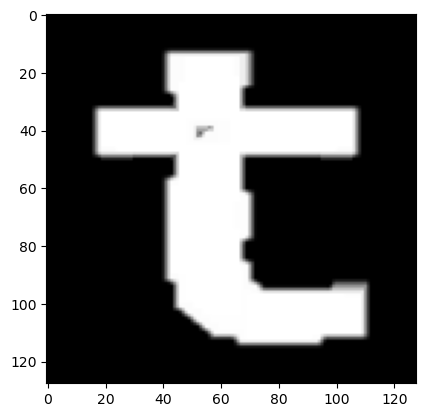

[0.0413571915421292, 0.0386840771664577, 0.03755513729006984]
1.069101154052844
Predicted label for test image: O


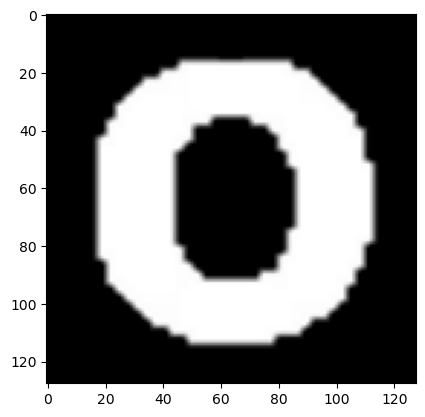

[0.04232247702223234, 0.03920152805113821, 0.03816675234806139]
1.0796129417971376
Predicted label for test image: e


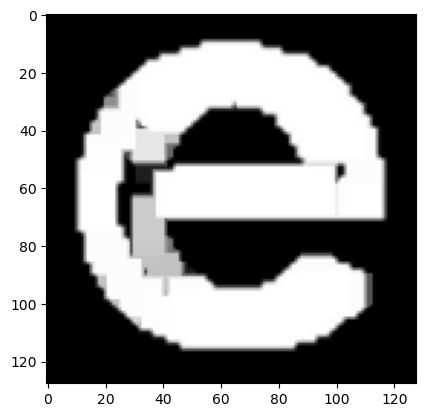

[0.039808407147442826, 0.038326968732946415, 0.035595856381116654]
1.0386526371239724
Predicted label for test image: X


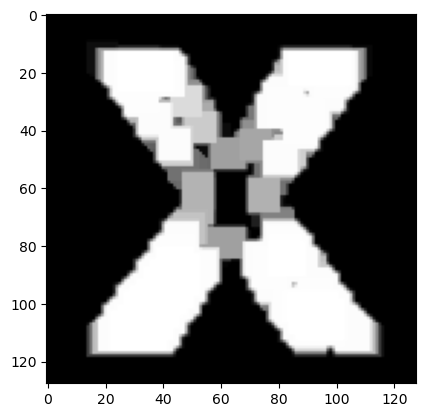

[0.04145568185409992, 0.03826086579799196, 0.036372629174881925]
1.083500882415359
Predicted label for test image: t


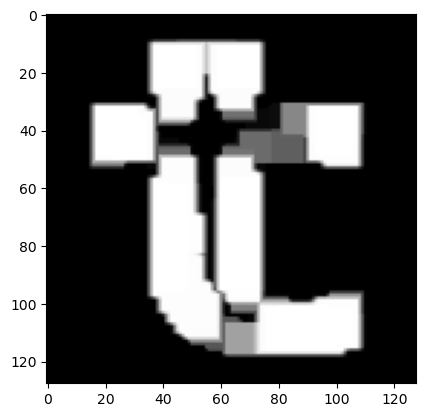

[0.039426478801006345, 0.03770262707004613, 0.03708364122332397]
1.0457223240109381
Predicted label for test image: T


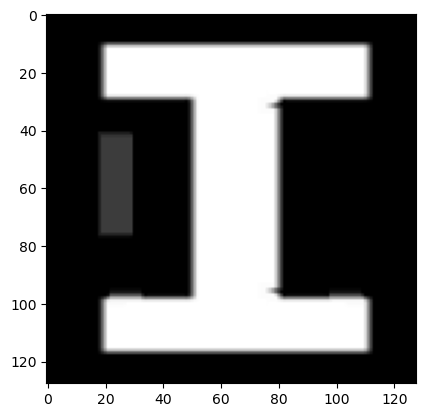

[0.04179983050773786, 0.041730396410067656, 0.038233211941923646]
1.001663873426648
Predicted label for test image: M


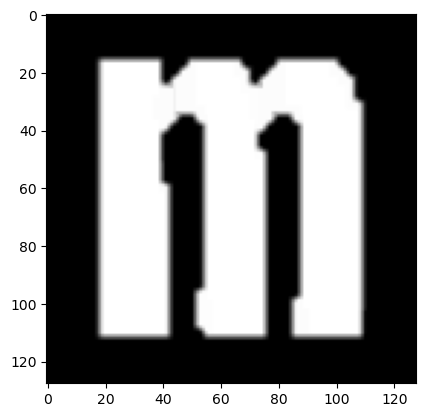

[0.04231903547968414, 0.03980649310493636, 0.03664427046091008]
1.0631189079662031
Predicted label for test image: a


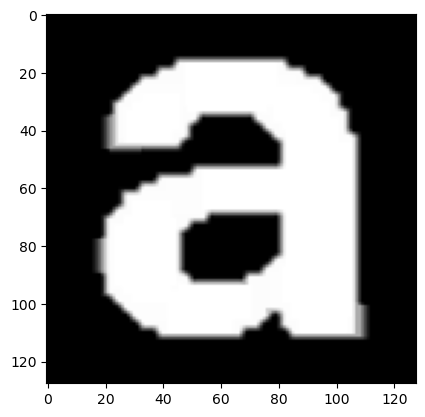

[0.04094831327095726, 0.038262593882261955, 0.03778603761954736]
1.0701917752089558
Predicted label for test image: g


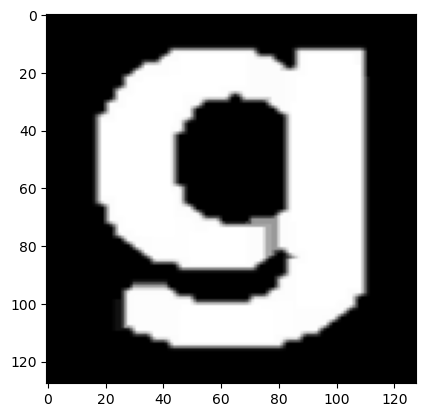

[0.04248038297275261, 0.04068645536307237, 0.039087983041082706]
1.0440915187541366
Predicted label for test image: e


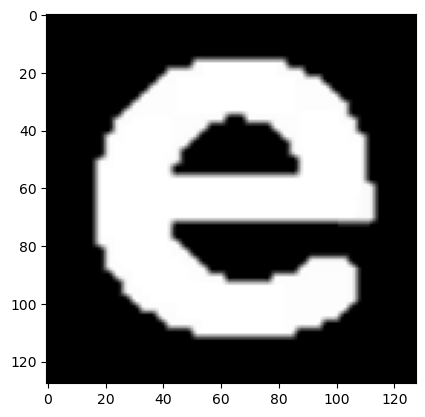

[0.04155621450435563, 0.03970005312868321, 0.03828083301497028]
1.0467546320317478
Predicted label for test image: O


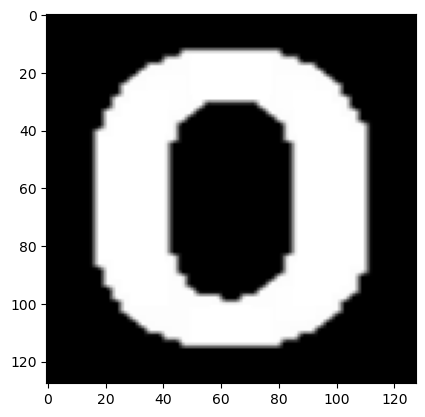

[0.04238609975556692, 0.037699880868125195, 0.03768675863803184]
1.124303281059009
Predicted label for test image: n


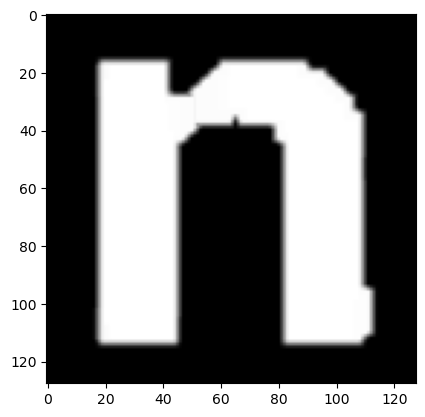

[0.040498274952450584, 0.03761434035735576, 0.03680742556034669]
1.076671146368538
Predicted label for test image: L


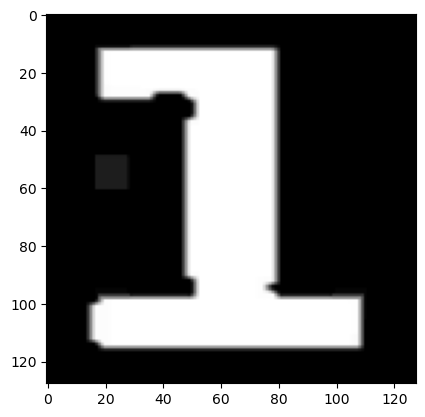

[0.040408189948592965, 0.04038898630456283, 0.036191703880933374]
1.00047546734363
Predicted label for test image: 1


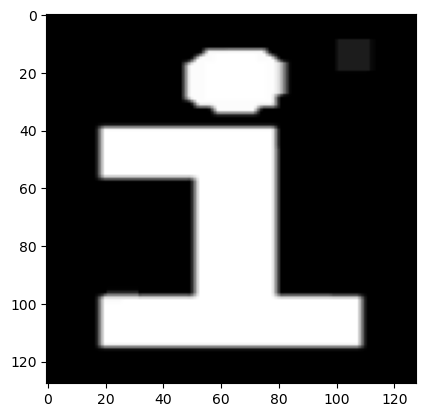

[0.042456777037242314, 0.04006290035762585, 0.03786023535877177]
1.059752954934547
Predicted label for test image: n


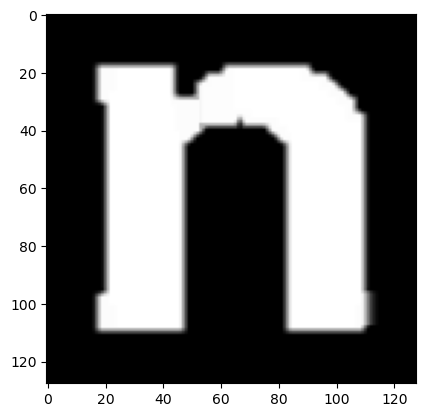

[0.04247696364045024, 0.04055602282315972, 0.0394054803999871]
1.0473651182628678
Predicted label for test image: e


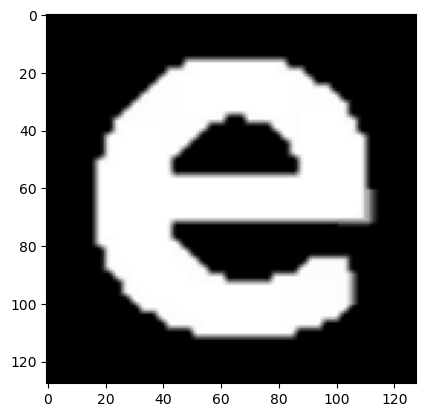

[0.041025062078077365, 0.038428669023303635, 0.037874407078505]
1.0675639599487363
Predicted label for test image: E


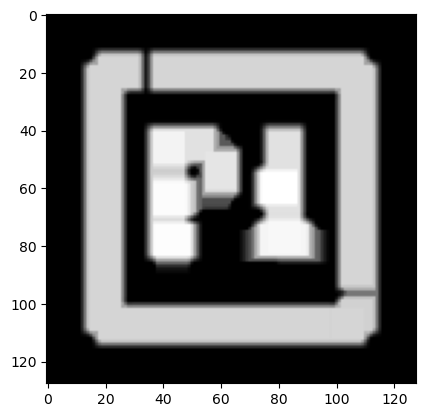

In [14]:
unique_boxes = sort_boxes_reading_order(unique_boxes, y_thresh=10)
words = merge_char_words(unique_boxes, x_thresh=20, y_thresh=30)
print(f"Number of words: {len(words)}")
text = ""
for word in words:
    for box in word:
        x, y, w, h = box
        # print(f"width: {w}, height: {h}")
        # print(f"Box {i}: x={x}, y={y}")
        char_img = gray[y:y+h, x:x+w]
        # plt.imshow(char_img, cmap='gray')
        # plt.show()
        
        ## border
        padded_char_img = cv2.copyMakeBorder(char_img, 5, 5, 5, 5, cv2.BORDER_CONSTANT, value=255)
        ## blur
        blurred_char_img = cv2.GaussianBlur(padded_char_img, (5, 5), 0)

        ## binarize
        binarized_char_img = cv2.adaptiveThreshold(
            blurred_char_img,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV,
            11,
            2
        )

        
        ## resize
        resized_char_img = cv2.resize(
            binarized_char_img,
            (128, 128),
            interpolation=cv2.INTER_CUBIC
        )

        ## erode and dilate
        eroded = cv2.erode(resized_char_img, np.ones((5, 5), np.uint8), iterations=2)
        dilated = cv2.dilate(eroded, np.ones((3, 3), np.uint8), iterations=5)

        ## normalized
        normalized_char_img = dilated.astype(np.float32) / 255.0

        magnitudes, orientations = calc_gradients(normalized_char_img)
        features = HoG(orientations, magnitudes)
        # predicted_label, scores = predict(features)
        # char_non_char_pred = char_non_char_model.predict(features.reshape(1, -1))
        # if char_non_char_pred == 0:
        #     print("Non-character detected, skipping...")
        #     continue
        # print(f"char_non_char_pred: {char_non_char_pred}")
        predicted_label, confidence = predict_char(features, model, le)
        props = model.predict_proba(features.reshape(1, -1))
        top3 = sorted(props[0], reverse=True)[:3]
        print(top3)
        print(top3[0]/top3[1])
        print("Predicted label for test image:", le.inverse_transform(predicted_label)[0])
        plt.imshow(normalized_char_img, cmap='gray')
        plt.show()
        text += le.inverse_transform(predicted_label)[0]
        text += " "
    # text += " "

In [ ]:
toLower = text.lower()
print(toLower)

a t x o e x m a e o n l n 
